In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import selfies as sf
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import math
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from sklearn.metrics import r2_score
from IPython.display import display
import seaborn as sns
import os
import re
torch.cuda.empty_cache()

import sys
sys.path.append('/home/andrze06/venvs/mlenv/lib/python3.10/site-packages/rdkit/Contrib/SA_Score')
import sascorer

In [2]:
df = pd.read_pickle('/data/home2/andrze06/projects/Smiles-latent-project/data/smiles_selfies_distance-matrix_dataset.pkl')

In [3]:
# Data & Loaders
df['tokens'] = df['selfies'].apply(lambda x: list(sf.split_selfies(x)))
vocab = sorted(set([tok for seq in df['tokens'] for tok in seq]))
PAD, SOS, EOS = "<PAD>", "<SOS>", "<EOS>"
vocab = [PAD, SOS, EOS] + vocab
vocab_size = len(vocab)

tok2id = {tok: idx for idx, tok in enumerate(vocab)}
id2tok = {idx: tok for idx, tok in enumerate(vocab)}

def molecule_tok2id(tokens, tok2id):
    return np.array([1] + [tok2id[t] for t in tokens] + [2])

df['token_ids'] = df['tokens'].apply(lambda x: molecule_tok2id(x, tok2id))
df['lengths'] = df['tokens'].apply(lambda x: len(x))

# padding
sequences = df['token_ids'].tolist()
max_len = max(len(seq) for seq in sequences)

X_train, X_temp, D_train, D_temp = train_test_split(sequences, df['distance_matrix'].tolist(), test_size=0.2, random_state=42, shuffle=True)
X_val, X_test, D_val, D_test = train_test_split(X_temp, D_temp, test_size=0.5, random_state=42, shuffle=True)

class MoleculeDataset(Dataset):
    def __init__(self, X, D):
        self.X = X
        self.D = D

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        tokens = self.X[index]
        dist_matrix = self.D[index]
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(dist_matrix, dtype=torch.long)
    
train_data = MoleculeDataset(X_train, D_train)
val_data = MoleculeDataset(X_val, D_val)
test_data = MoleculeDataset(X_test, D_test)
data = MoleculeDataset(sequences, df['distance_matrix'].tolist())

In [5]:
# utilities
def collate_fn(batch):
    tokens_list, dist_list = zip(*batch)
    max_len = max(t.shape[0] for t in tokens_list)
    B = len(tokens_list)

    padded_sequence = torch.zeros((B, max_len), dtype=torch.long)
    padded_dist = torch.full((B, max_len, max_len), fill_value=-1, dtype=torch.int16)

    for i, (tokens, dist) in enumerate(zip(tokens_list, dist_list)):
        n = tokens.shape[0]
        padded_sequence[i, :len(tokens)] = tokens
        padded_dist[i, 1:len(dist)+1, 1:len(dist)+1] = dist

    return padded_sequence, padded_dist 

@torch.no_grad()
def accuracy(model, loader, mode='eval', pad_id=0, device='cuda'):
    model.eval()

    total_correct = 0
    total_tok = 0
    total_seq = 0
    perfect = 0

    for x, D in loader:
        x, D = x.to(device), D.to(device)

        if mode == 'train':
            logits, _, _, _ = model(x, D, mode=mode)
            targets = x[:, 1:]

            pred = logits.argmax(dim=-1)

            mask = (targets != pad_id)

            correct = (pred == targets) & mask

            total_correct += correct.sum().item()
            total_tok += mask.sum().item()

            seq_correct = (correct.sum(dim=1) == mask.sum(dim=1))
            perfect += seq_correct.sum().item()
            total_seq += x.size(0)

        else:
            tokens, _, _, _ = model(x, D, mode='eval')

            for i, pred in enumerate(tokens):
                true = x[i]
                mask = (true != pad_id)
                true_len = mask.sum().item()

                if true_len == 0:
                    continue
                if len(pred) < true_len:
                    pad = torch.full((true_len - len(pred),), pad_id, device=pred.device, dtype=pred.dtype)
                    pred = torch.cat([pred, pad], dim=0)
                else:
                    pred = pred[:true_len]

                true = true[:true_len]
                correct = (pred == true)
                total_correct += correct.sum().item()
                total_tok += true_len
                perfect += int(correct.all())
                total_seq += 1

    return (
        total_correct / max(total_tok, 1),
        perfect / max(total_seq, 1)
    )

def check_on_SA(model, loader, devce='cuda'):
    model.eval()

def set_token_ticks(ax, tokens, max_show=30):
    n = len(tokens)

    step = max(1, n // max_show)
    idxs = list(range(0, n, step))

    labels = [tokens[i] for i in idxs]

    ax.set_xticks(idxs)
    ax.set_yticks(idxs)

    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

def cleaned_selfie(tokens, pad="<PAD>", sos="<SOS>", eos="<EOS>"):
    out = []
    for t in tokens:
        if t == eos:
            break
        if t in (pad, sos):
            continue
        out.append(t)
    return out
    

In [7]:
# model
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        pe = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_size, 2).float() * (-math.log(10000.0) / hidden_size))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        if x.dim() == 3:
            B, T, _ = x.shape
        elif x.dim() == 2:
            B, T = x.shape
        if T <= self.pe.size(0):
            pe = self.pe[:T]  
        else:
            device = x.device
            H = self.hidden_size
            position = torch.arange(T, dtype=torch.float, device=device).unsqueeze(1)  
            div_term = torch.exp(torch.arange(0, H, 2, device=device).float() * (-math.log(10000.0)/H))
            pe = torch.zeros(T, H, device=device)
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  

class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.d = hidden_size // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, 2*hidden_size),
            nn.GELU(),
            nn.Dropout(p=0.1),
            nn.Linear(2*hidden_size, hidden_size),
            nn.Dropout(p=0.1)
        )
        self.norm2 = nn.LayerNorm(hidden_size)

    def forward(self, q, k, v, pad_mask=None):   # [B, T, H]
        # q,k,v: attention values, D: molecule distance matrix (selfies) [B, T, T], alpha: how much D should influence attention
        B, T_q, H = q.shape
        _, T_v, _ = v.shape
        Q = self.W_q(q)     # [B, T, num_heads * H]
        K = self.W_k(k)
        V = self.W_v(v)
        Q = Q.view(B, self.num_heads, T_q, self.d) # [B, A, T, H]
        K = K.view(B, self.num_heads, T_v, self.d)
        V = V.view(B, self.num_heads, T_v, self.d)

        attn_logits = torch.einsum('baih,bajh->baij', Q, K)    # [B, A, T, H] @ [B, A, H, T] = [B, A, T, T]

        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]  # [B,1,1,T_k]
            attn_logits = attn_logits.masked_fill(~key_mask, float('-inf'))

        attn = F.softmax(attn_logits / math.sqrt(self.d), dim=-1)

        if pad_mask is not None:
            query_mask = pad_mask[:, None, :, None]  # [B,1,T_q,1]
            attn = attn * query_mask.float()

        h = torch.einsum('baij,bajh->baih',attn, V)  # [B, A, T, H]
        h = h.view(B, T_q, H)  # [B, T, A*H]
        h = self.W_o(h)     # [B, T, H]
        
        h = q + self.W_o(h)     # [B, T, H]
        h = h + self.ff(self.norm2(h))
        h = self.norm1(h)
        return h, attn

class MultiSlotPooling(nn.Module):
    def __init__(self, hidden_size, num_slots):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(num_slots, hidden_size))
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, h, mask):
        # h: [B, T, D]
        # mask: [B, T]
        k = self.W_k(h)
        v = self.W_v(h)
        attn = torch.einsum("kd,btd->bkt", self.queries, k)
        attn = attn.masked_fill(~mask[:, None, :], -1e9)
        attn = F.softmax(attn, dim=-1)
        slots = torch.einsum("bkt,btd->bkd", attn, v)
        return slots


class VaeTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, latent_size, max_len, attn_heads=8, num_slots=8, encoder_layers=1, decoder_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_slots = num_slots
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEmbedding(max_len, hidden_size)
        self.conv_pos = nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1, groups=hidden_size)
        
        # Encoder
        self.pos_block = MultiHeadAttention(hidden_size, attn_heads)
        self.encoder_blocks = nn.ModuleList([MultiHeadAttention(hidden_size, attn_heads) for _ in range(encoder_layers)])
        self.pool = MultiSlotPooling(hidden_size, num_slots=num_slots)
        #self.slot_pos_encoder = nn.Parameter(torch.randn(1, num_slots, hidden_size))
        self.slots_mix = MultiHeadAttention(hidden_size, num_heads=num_slots)

        self.slot_gamma = nn.Parameter(torch.ones(1, num_slots, hidden_size))
        self.slot_beta = nn.Parameter(torch.zeros(1, num_slots, hidden_size))
        #nn.init.orthogonal_(self.slot_beta[0])

        # VAE heads
        self.slot_mu = nn.Linear(hidden_size, latent_size)
        self.slot_logvar = nn.Linear(hidden_size, latent_size)  
        
        self.slot_compress_mu = nn.Linear(hidden_size, latent_size // num_slots)
        self.slot_compress_logvar = nn.Linear(hidden_size, latent_size // num_slots)

        self.fc_mu = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)
        
        # pooling in latent space with uncertanty
        self.latent_query = nn.Parameter(torch.randn(1, 1, latent_size))
        self.latent_key = nn.Linear(latent_size, latent_size)

        # Decoder
        self.max_len = max_len
        self.z_to_slot = nn.Linear(hidden_size // num_slots, hidden_size)
        #self.slot_pos_decoder = nn.Parameter(torch.randn(1, num_slots, hidden_size))
        self.decoder_embed = nn.Embedding(vocab_size, hidden_size)

        self.decoder_pos = PositionalEmbedding(max_len, hidden_size)

        self.z_to_memory = nn.Linear(latent_size, hidden_size)
        self.slots_to_memory = nn.Linear(latent_size // num_slots, hidden_size)

        self.decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=attn_heads,
            dim_feedforward=2 * hidden_size,
            batch_first=True
        )

        self.decoder_transformer = nn.TransformerDecoder(
            self.decoder_layer,
            num_layers=decoder_layers
        )
        # Output head
        self.fc_output = nn.Linear(hidden_size, vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def causal_mask(self, T, device):
        return torch.triu(
            torch.ones(T, T, device=device),
            diagonal=1
        ).bool()
    
    def encode(self, x, D, mode=None):  
        B, _ = x.shape
        h = self.embedding(x)    # [B, T, H]
        fourier_pos_encoding = self.pos_encoder(x)
        # invalid_tokens = (D == -1).all(dim=-1)   # [B, T]
        # fourier_pos_encoding = fourier_pos_encoding.masked_fill(invalid_tokens[:, :, None],0.0)
        h = h + fourier_pos_encoding

        # D_mix = 1.0 / (1.0 + torch.clamp(D.float(), min=0))
        # D_mix = D_mix.masked_fill(D == -1, 0.0) 
        # h = torch.einsum("bij,bjh->bih", D_mix, h)

        mask = (x != 0)
        
        for block in self.encoder_blocks:
            h, attn_matrix = block(h, h, h, pad_mask=mask)
            
        h = h.masked_fill(~mask[:, :, None], 0.0)

        # h = h.sum(dim=1) / mask.sum()
        # mu = self.fc_mu(h)
        # logvar = self.fc_logvar(h)
        slots = self.pool(h, mask)
        slots = F.layer_norm(slots, slots.shape[-1:])
        #slots = slots * self.slot_gamma + self.slot_beta

        B, K, Z = slots.shape

        slots_mu = self.slot_mu(slots)
        slots_logvar = self.slot_logvar(slots)

        # Latent pool from slots with uncertanty
        q = F.normalize(self.latent_query.expand(B, 1, Z), dim=-1)
        k = F.normalize(self.latent_key(slots_mu), dim=-1)

        logits = torch.einsum("bqz,bkz->bqk", q, k)

        confidence = -torch.logsumexp(slots_logvar, dim=-1).unsqueeze(1) #-slots_logvar.mean(dim=-1).unsqueeze(1)
        confidence_scale = 0.5

        logits = logits + confidence_scale * confidence
        attn = torch.softmax(logits / 0.5, dim=-1)

        mu = torch.einsum("bqk,bkz->bqz", attn, slots_mu).squeeze(1)

        var = torch.exp(slots_logvar)
        var_agg = torch.einsum("bqk,bkz->bqz", attn, var).squeeze(1)
        logvar = torch.log(var_agg + 1e-8)
        
        if mode == "test":
            return mu, logvar, attn_matrix
        else:
            return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, x_in=None, max_len=80, start_id=1, eos_id=2):
        B = z.size(0)
        device = z.device

        memory = self.z_to_memory(z).unsqueeze(1)

        if x_in is not None:
            x_emb = self.decoder_embed(x_in)
            x_emb = x_emb + self.decoder_pos(x_emb)

            T = x_emb.size(1)
            tgt_mask = self.causal_mask(T, device)

            h = self.decoder_transformer(
                tgt=x_emb,
                memory=memory,
                tgt_mask=tgt_mask
            )

            logits = self.fc_output(h)   
            return logits

        else:
            tokens = torch.full((B, 1), start_id, dtype=torch.long, device=device)
            finished = torch.zeros(B, dtype=torch.bool, device=device)
            max_len = self.max_len * 2

            for _ in range(max_len):
                x_emb = self.decoder_embed(tokens)
                x_emb = x_emb + self.decoder_pos(x_emb)

                T = tokens.size(1)
                tgt_mask = self.causal_mask(T, device)

                h = self.decoder_transformer(
                    tgt=x_emb,
                    memory=memory,
                    tgt_mask=tgt_mask
                )

                logits_step = self.fc_output(h[:, -1])  # [B, V]

                next_token = torch.argmax(logits_step, dim=-1, keepdim=True)

                next_token = torch.where(
                    finished.unsqueeze(1),
                    torch.full_like(next_token, eos_id),
                    next_token
                )

                tokens = torch.cat([tokens, next_token], dim=1)

                finished |= (next_token.squeeze(1) == eos_id)

                if finished.all():
                    break

            return tokens
            
    def forward(self, x, D, mode='eval'):
        mu, logvar = self.encode(x, D)
        z = self.reparameterize(mu, logvar)

        if mode == 'train':
            x_in = x[:, :-1]

            logits = self.decode(z, x_in=x_in)

            return logits, mu, logvar, z
    
        if mode == "eval":
            tokens = self.decode(z, x_in=None)

            return tokens, mu, logvar, z
        
        if mode == "test":
            mu, logvar, attn_matrix = self.encode(x, D, mode="test")
            z = self.reparameterize(mu, logvar)

            tokens = self.decode(z, x_in=None)

            return tokens, mu, logvar, attn_matrix, z


def vae_loss(logits, targets, mu, logvar, beta=0.01, pad_id=0):
    B, T, V = logits.shape

    logits = logits.reshape(-1, V)
    targets = targets.reshape(-1)

    rec_loss = F.cross_entropy(
        logits,
        targets,
        ignore_index=pad_id
    )

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return rec_loss + beta * kl, rec_loss, kl

In [8]:
# training
device = 'cuda' if torch.cuda.is_available() else 'cpu'

hidden_size = 256
attention_heads = 8
num_slots = 8
encoder_layers = 3
decoder_layers = 2
latent_size = 256

model = VaeTransformer(vocab_size, hidden_size, latent_size, max_len, attn_heads=attention_heads, num_slots=num_slots, encoder_layers=encoder_layers, decoder_layers=decoder_layers).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

beta = 0.01
epochs = 50
batch_size = 256
history = []

train_loader = DataLoader(train_data, batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_data, batch_size, shuffle=False, collate_fn=collate_fn)

for epoch in range(1, epochs+1):
    #beta = min(0.5, beta + epoch/30)
    model.train()
    total = 0
    total_rec = 0
    total_kl = 0
    total_val = 0
    pbar = tqdm(train_loader)

    for x, D in pbar:
        x, D = x.to(device), D.to(device) 
        logits, mu, logvar, z = model(x, D=None, mode='train')
        x = x[:, 1:]
        loss, rec, kl = vae_loss(logits, x, mu, logvar, beta=beta)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pbar.set_postfix({
            "rec": f"{rec.item():.3f}",
            "kl": f"{kl.item():.3f}", 
            "tot": f"{loss.item():.3f}",
        })
        total += loss.item()
        total_rec += rec.item()
        total_kl += kl.item()

    with torch.no_grad():
        model.eval()
        for x, D in val_loader:
            x, D = x.to(device), D.to(device)
            logits, mu, logvar, z = model(x, D, mode='train')
            x = x[:, 1:]
            val_loss, val_rec, val_kl = vae_loss(
                logits, x, mu, logvar, 
                beta=beta
            )
            total_val += val_loss.item()

    token_acc, seq_acc = accuracy(model, val_loader, mode='train')
    total = total / len(train_loader)
    total_rec = total_rec / len(train_loader)
    total_kl = total_kl / len(train_loader)
    total_val = total_val / len(val_loader)
    history.append((total, total_rec, total_kl, total_val))
    print(f"Epoch: {epoch:03d} | total={total:.4f} | rec={total_rec:.4f} | kl={total_kl:.4f} | val={total_val:.4f} | token_acc={token_acc*100:.2f}% | seq_acc={seq_acc*100:.2f}%")

100%|███████████████████| 2483/2483 [02:16<00:00, 18.25it/s, rec=0.496, kl=2.460, tot=0.520]


Epoch: 001 | total=1.0423 | rec=1.0216 | kl=2.0668 | val=0.3823 | token_acc=87.80% | seq_acc=11.21%


100%|███████████████████| 2483/2483 [02:13<00:00, 18.66it/s, rec=0.298, kl=2.426, tot=0.322]


Epoch: 002 | total=0.3848 | rec=0.3601 | kl=2.4675 | val=0.1991 | token_acc=93.90% | seq_acc=30.46%


100%|███████████████████| 2483/2483 [02:19<00:00, 17.78it/s, rec=0.201, kl=2.370, tot=0.225]


...

Epoch: 048 | total=0.0347 | rec=0.0242 | kl=1.0582 | val=0.0168 | token_acc=99.80% | seq_acc=93.75%


100%|███████████████████| 2483/2483 [02:30<00:00, 16.50it/s, rec=0.027, kl=1.101, tot=0.038]


Epoch: 049 | total=0.0344 | rec=0.0239 | kl=1.0552 | val=0.0169 | token_acc=99.79% | seq_acc=93.68%


100%|███████████████████| 2483/2483 [02:25<00:00, 17.04it/s, rec=0.016, kl=1.017, tot=0.026]


Epoch: 050 | total=0.0342 | rec=0.0237 | kl=1.0520 | val=0.0167 | token_acc=99.78% | seq_acc=93.40%


In [14]:
# utils
def get_molecule_properties(mol):
    return {
        "molWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "cLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumSpiroAtoms": rdMolDescriptors.CalcNumSpiroAtoms(mol),
        "NumBridgeheadAtoms": rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "QED": QED.qed(mol),
        "SA-score": sascorer.calculateScore(mol)
    }

def compute_property(mol, name):
    if name == "molWt":
        return Descriptors.MolWt(mol)
    elif name == "HeavyAtomCount":
        return mol.GetNumHeavyAtoms()
    elif name == "cLogP":
        return Descriptors.MolLogP(mol)
    elif name == "TPSA":
        return Descriptors.TPSA(mol)
    elif name == "HBD":
        return rdMolDescriptors.CalcNumHBD(mol)
    elif name == "HBA":
        return rdMolDescriptors.CalcNumHBA(mol)
    elif name == "NumRotatableBonds":
        return rdMolDescriptors.CalcNumRotatableBonds(mol)
    elif name == "RingCount":
        return rdMolDescriptors.CalcNumRings(mol)
    elif name == "AromaticRingCount":
        return rdMolDescriptors.CalcNumAromaticRings(mol)
    elif name == "FractionCSP3":
        return rdMolDescriptors.CalcFractionCSP3(mol)
    elif name == "NumSpiroAtoms":
        return rdMolDescriptors.CalcNumSpiroAtoms(mol)
    elif name == "NumBridgeheadAtoms":
        return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    elif name == "BertzCT":
        return Descriptors.BertzCT(mol)
    elif name == "QED":
        return QED.qed(mol)
    elif name == "SA-score":
        return sascorer.calculateScore(mol)
    else:
        return np.nan

def clean_selfie_ids(ids):
    result = []
    for tok in ids:
        if tok == 1:
            continue
        if tok == 2 or tok == 0:
            return result
        result.append(tok)
    return result

def latents_to_mol(model, z):
    ids = model.decode(z)
    tokens = [[id2tok[id] for id in clean_selfie_ids(seq)] for seq in ids.cpu().numpy()]
    selfies = [''.join(toks) for toks in tokens]
    mols = []
    for selfie in selfies:
        try:
            smi = sf.decoder(selfie)
            mol = Chem.MolFromSmiles(smi)
            mols.append(mol)  
        except:
            mols.append(None)
            print(smi)
    return mols

def set_token_ticks(ax, tokens, max_show=30):
    n = len(tokens)

    step = max(1, n // max_show)
    idxs = list(range(0, n, step))

    labels = [tokens[i] for i in idxs]

    ax.set_xticks(idxs)
    ax.set_yticks(idxs)

    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

def cleaned_selfie(tokens, pad="<PAD>", sos="<SOS>", eos="<EOS>"):
    out = []
    for t in tokens:
        if t == eos:
            break
        if t in (pad, sos):
            continue
        out.append(t)
    return out

In [10]:
Y = pd.read_csv('/data/home2/andrze06/projects/Smiles-latent-project/data/molecule_properties.csv')
X = pd.read_csv('/data/home2/andrze06/projects/Smiles-latent-project/data/confound_features.csv')    

In [11]:
n = len(Y) // 100
latent_size = latent_size
batch_size = 2048

Sampled_properties = []
with torch.no_grad():
    for i in tqdm(range(0, n, batch_size)):
        z = torch.randn((min(batch_size, n - i), latent_size)).to(device)
        mols = latents_to_mol(model, z)
        for mol in mols:
            if mol is not None:
                props = get_molecule_properties(mol)
                Sampled_properties.append(props)
            else:
                Sampled_properties.append(None)

100%|█████████████████████████████████████████████████████████| 4/4 [00:21<00:00,  5.29s/it]


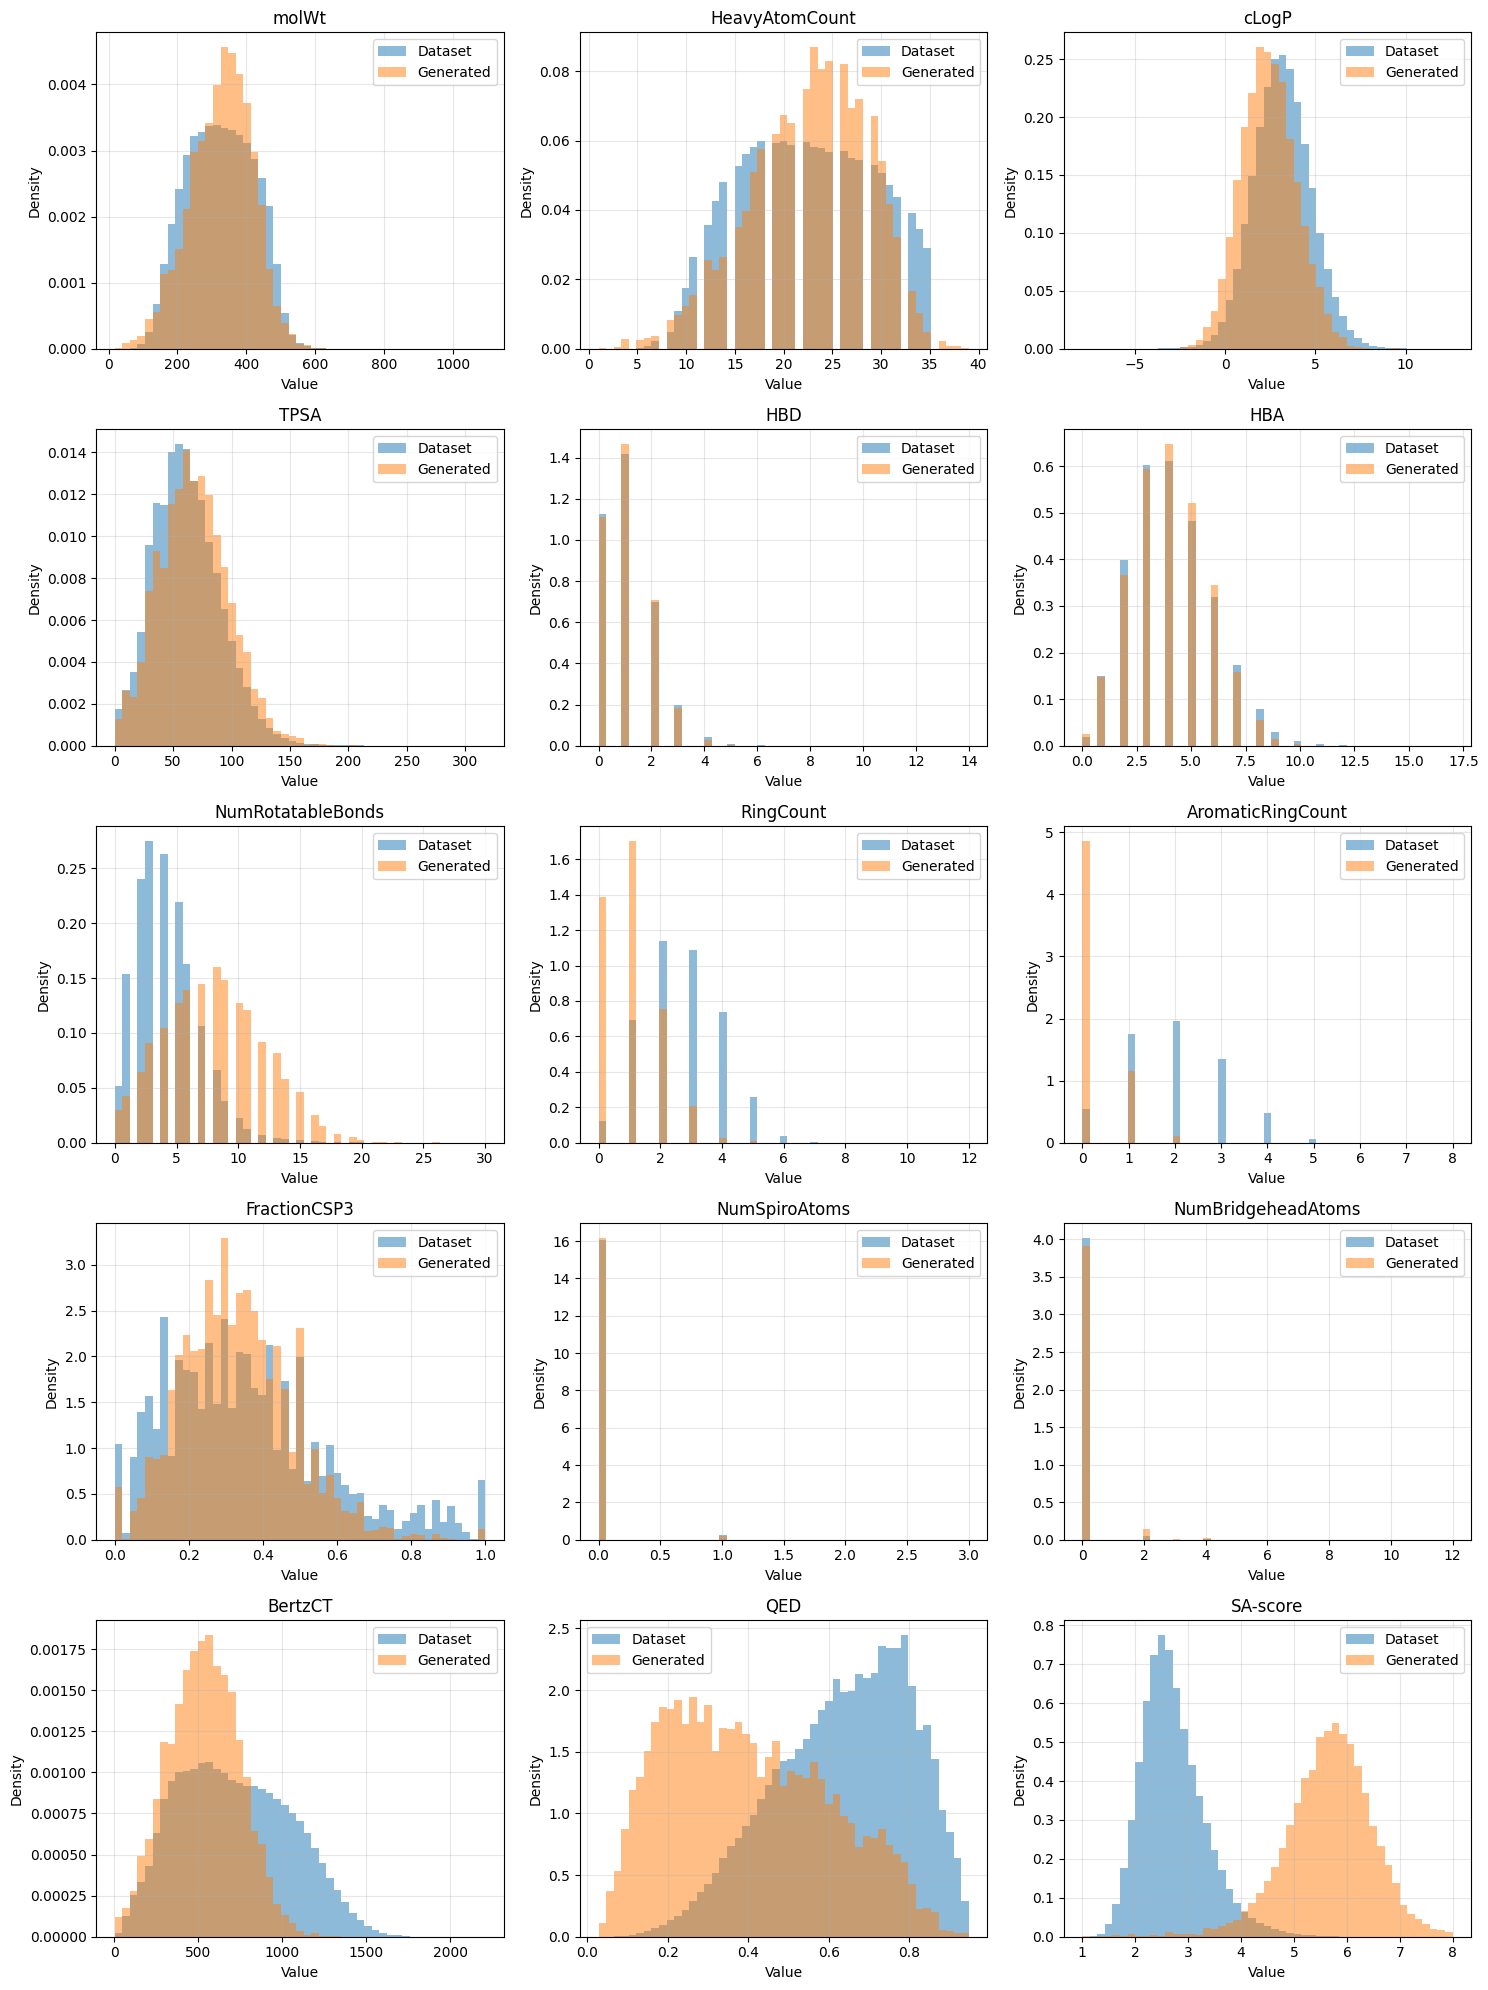

In [12]:
# plots
prop_dict = defaultdict(list)

for props in Sampled_properties:
    if props is None:
        continue
    for k, v in props.items():
        if v is not None and not np.isnan(v):
            prop_dict[k].append(v)

cols = Y.columns
n_cols = len(cols)

n_rows = math.ceil(n_cols / 3)
n_cols_grid = 3

fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    gen_vals = prop_dict.get(col, [])

    if len(gen_vals) == 0:
        continue

    data_vals = Y[col].dropna()

    combined = np.concatenate([data_vals.values, gen_vals])
    bins = np.linspace(combined.min(), combined.max(), 50)

    axes[i].hist(data_vals, bins=bins, alpha=0.5, label="Dataset", density=True)
    axes[i].hist(gen_vals, bins=bins, alpha=0.5, label="Generated", density=True)

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].grid(alpha=0.3)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
# examples:
def tokens_to_selfie(tokens):
    selfie_tokens = [id2tok[int(t)] for t in tokens]
    return "".join(selfie_tokens)

model.eval()
with torch.no_grad():
    for x, D in val_loader:
        x, D = x.to(device), D.to(device)
        tokens, _, _, attn_matrix, _ = model(x, D, mode='test')
        for i in range(5):
            toks = tokens[i]
            print(tokens_to_selfie(x[i]))
            print(tokens_to_selfie(toks))
            print("")
        break

<SOS>[C][CH2][CH2][CH0][=CH0][Branch2][Ring1][Branch2][CH0][=Branch1][C][=OH0][NH1][CH2][CH0][=CH1][CH1][=CH0][CH1][=CH0][Branch1][C][OH1][CH1][=CH1][CH0][Ring1][#Branch1][=CH1][Ring1][O][CH1][=NH0][NH0][Ring2][Ring1][Ring2][CH0][=CH1][CH1][=CH1][CH1][=CH1][Ring1][=Branch1]<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
<SOS>[C][CH2][CH2][CH0][=CH0][Branch2][Ring1][Branch2][CH0][=Branch1][C][=OH0][NH1][CH2][CH0][=CH1][CH1][=CH0][CH1][=CH0][Branch1][C][OH1][CH1][=CH1][CH0][Ring1][#Branch1][=CH1][Ring1][O][CH1][=NH0][NH0][Ring2][Ring1][Ring2][CH0][=CH1][CH1][=CH1][CH1][=CH1][Ring1][=Branch1]<EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS>

<SOS>[C][CH2][CH2][CH2][OH0][SH0][=Branch1][C][=OH0][=Branch1][C][=OH0][NH1][CH0][=Branch1][C][=OH0][/CH1][=CH1][/CH0][CH0][Branch1][C][CH3][=NH0][NH0][Branch1][C][CH3][CH0][=Ring1][#Branch1][NH0][CH1][=CH1][CH0][=CH1][CH0][Branc

<SOS>[C][NH1][CH1][Branch1][=Branch2][CH0][=CH1][CH1][=CH1][CH1][=CH1][Ring1][=Branch1][CH0][=CH1][CH0][Branch1][C][BrH0][=CH1][CH1][=CH0][Ring1][#Branch1][NH2]<EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS><EOS>


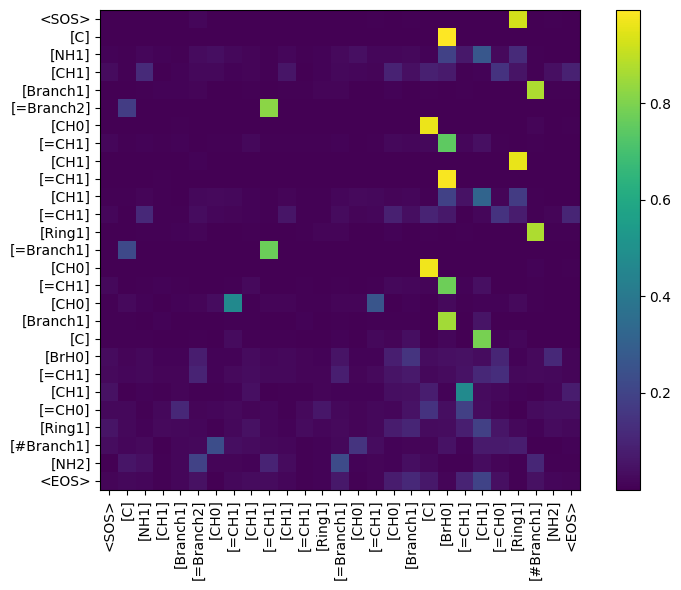

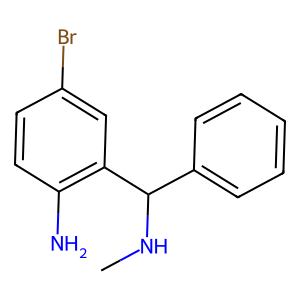

In [ ]:
# attention visualization
idx = np.random.randint(0, tokens.size(0))
toks = tokens[idx]

eos_id = 2
tokens_np = toks.detach().cpu().numpy()
eos_pos = np.where(tokens_np == eos_id)[0]

if len(eos_pos) > 0:
    cut = eos_pos[0] + 1   
else:
    cut = len(tokens_np)

valid_tokens = tokens_np[:cut]
selfies_tokens = [id2tok[int(t)] for t in valid_tokens]
selfies = tokens_to_selfie(toks)
print(selfies)

def crop_attn(A, cut):
    return A[:cut, :cut]

A1 = crop_attn(attn_matrix[idx][0].cpu(), cut)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(A1, cmap="viridis")

# tick labels only for visible tokens
ax.set_xticks(range(cut))
ax.set_yticks(range(cut))

ax.set_xticklabels(selfies_tokens, rotation=90)
ax.set_yticklabels(selfies_tokens)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
selfies_str = "".join(cleaned_selfie(selfies_tokens))

try:
    smiles = sf.decoder(selfies_str)
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("RDKit failed to parse SMILES")
    else:
        img = Draw.MolToImage(mol)
        display(img)
except Exception as e:
    print("SELFIES decode failed:", e)

In [31]:
zs = []
lenghts = []
with torch.no_grad():
    for i, (x, D) in enumerate(val_loader):
        x, D = x.to(device), D.to(device)
        mu, _ = model.encode(x, D)
        zs.append(mu.cpu().numpy()) 

        lenght = (x != 0).sum(dim=-1)
        lenghts.append(lenght.cpu().numpy())

        if i >= 100:
            print
            break

z = np.concatenate(zs, axis=0)
lenghts = np.concatenate(lenghts, axis=0)
print(z.shape, lenghts.shape)

(25856, 256) (25856,)


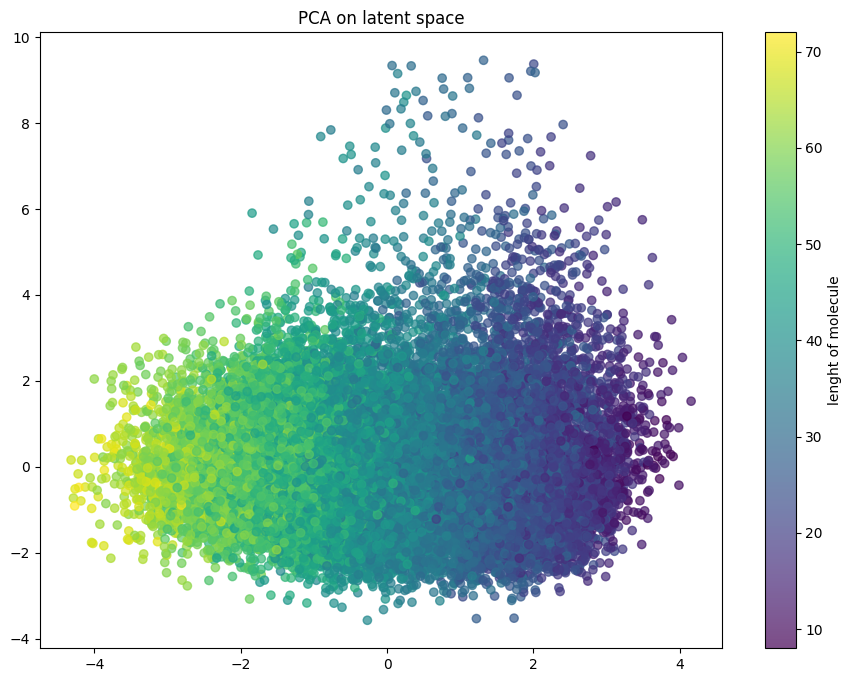

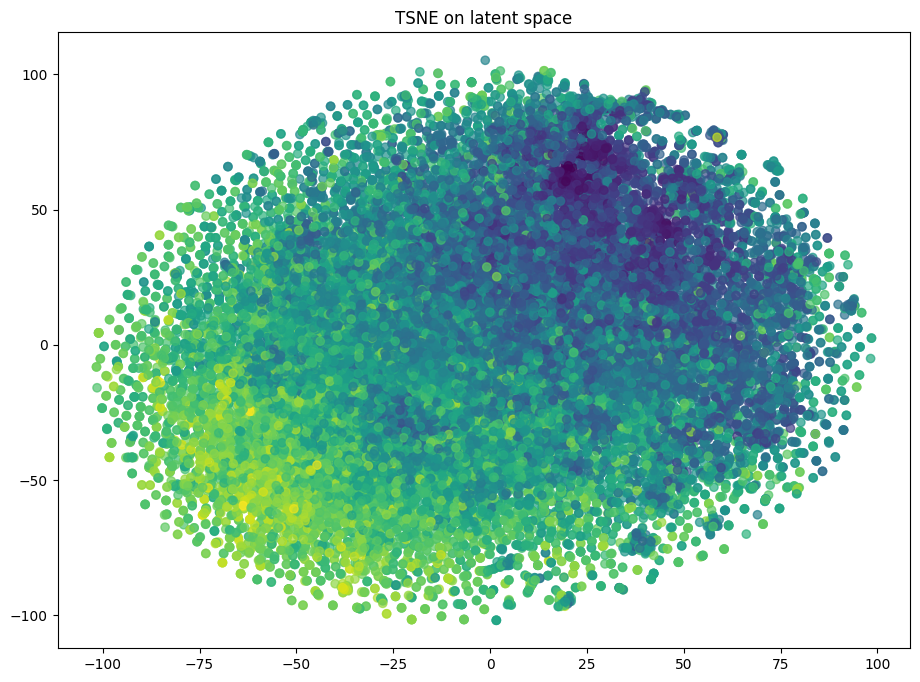

In [33]:
# visualizations
pca_z = PCA(n_components=2).fit_transform(z)
plt.figure(figsize=(11,8))
plt.scatter(pca_z[:, 0], pca_z[:, 1], c=lenghts, cmap='viridis', alpha=0.7)
plt.title('PCA on latent space')
plt.colorbar(label='lenght of molecule')
plt.show()

tsne_z = TSNE(n_components=2).fit_transform(z)
plt.figure(figsize=(11,8))
plt.scatter(tsne_z[:, 0], tsne_z[:, 1], c=lenghts, cmap='viridis', alpha=0.7)
plt.title('TSNE on latent space')
plt.show()

In [34]:
# extract latents for linear probe
def extract_latents(data, model):
    loader = DataLoader(data, batch_size=128, shuffle=False, collate_fn=collate_fn)
    zs = []
    model.eval()
    with torch.no_grad():
        for x, D in tqdm(loader):
            x, D = x.to(device), D.to(device)
            mu, _ = model.encode(x, D)
            zs.append(mu.cpu().numpy())
    z = np.concatenate(zs, axis=0)
    return z

z = extract_latents(data, model)

100%|███████████████████████████████████████████████████| 6207/6207 [01:30<00:00, 68.37it/s]


In [36]:
directions = []
for target_name in Y.columns:
    print(f"\n=== Predicting {target_name} ===")
    y = Y[target_name].values
    z_train, z_test, y_train, y_test = train_test_split(z, y, test_size=0.2, random_state=42)

    linear_probe = Pipeline([
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])

    linear_probe.fit(z_train, y_train)
    y_pred = linear_probe.predict(z_test)
    print("R2:", r2_score(y_test, y_pred))
    w = linear_probe.named_steps['linear'].coef_ / linear_probe.named_steps['scaler'].scale_
    w /= np.linalg.norm(w)
    directions.append(w)


=== Predicting molWt ===
R2: 0.9543767838851512

=== Predicting HeavyAtomCount ===
R2: 0.9818912744522095

=== Predicting cLogP ===
R2: 0.8103515734465376

=== Predicting TPSA ===
R2: 0.8941436207493344

=== Predicting HBD ===
R2: 0.8867213726043701

=== Predicting HBA ===
R2: 0.8558911085128784

=== Predicting NumRotatableBonds ===
R2: 0.7941145300865173

=== Predicting RingCount ===
R2: 0.9391034245491028

=== Predicting AromaticRingCount ===
R2: 0.9037472009658813

=== Predicting FractionCSP3 ===
R2: 0.905707699860439

=== Predicting NumSpiroAtoms ===
R2: 0.09543442726135254

=== Predicting NumBridgeheadAtoms ===
R2: 0.1500236988067627

=== Predicting BertzCT ===
R2: 0.96267405986825

=== Predicting QED ===
R2: 0.46064248650919914

=== Predicting SA-score ===
R2: 0.6319001723874546


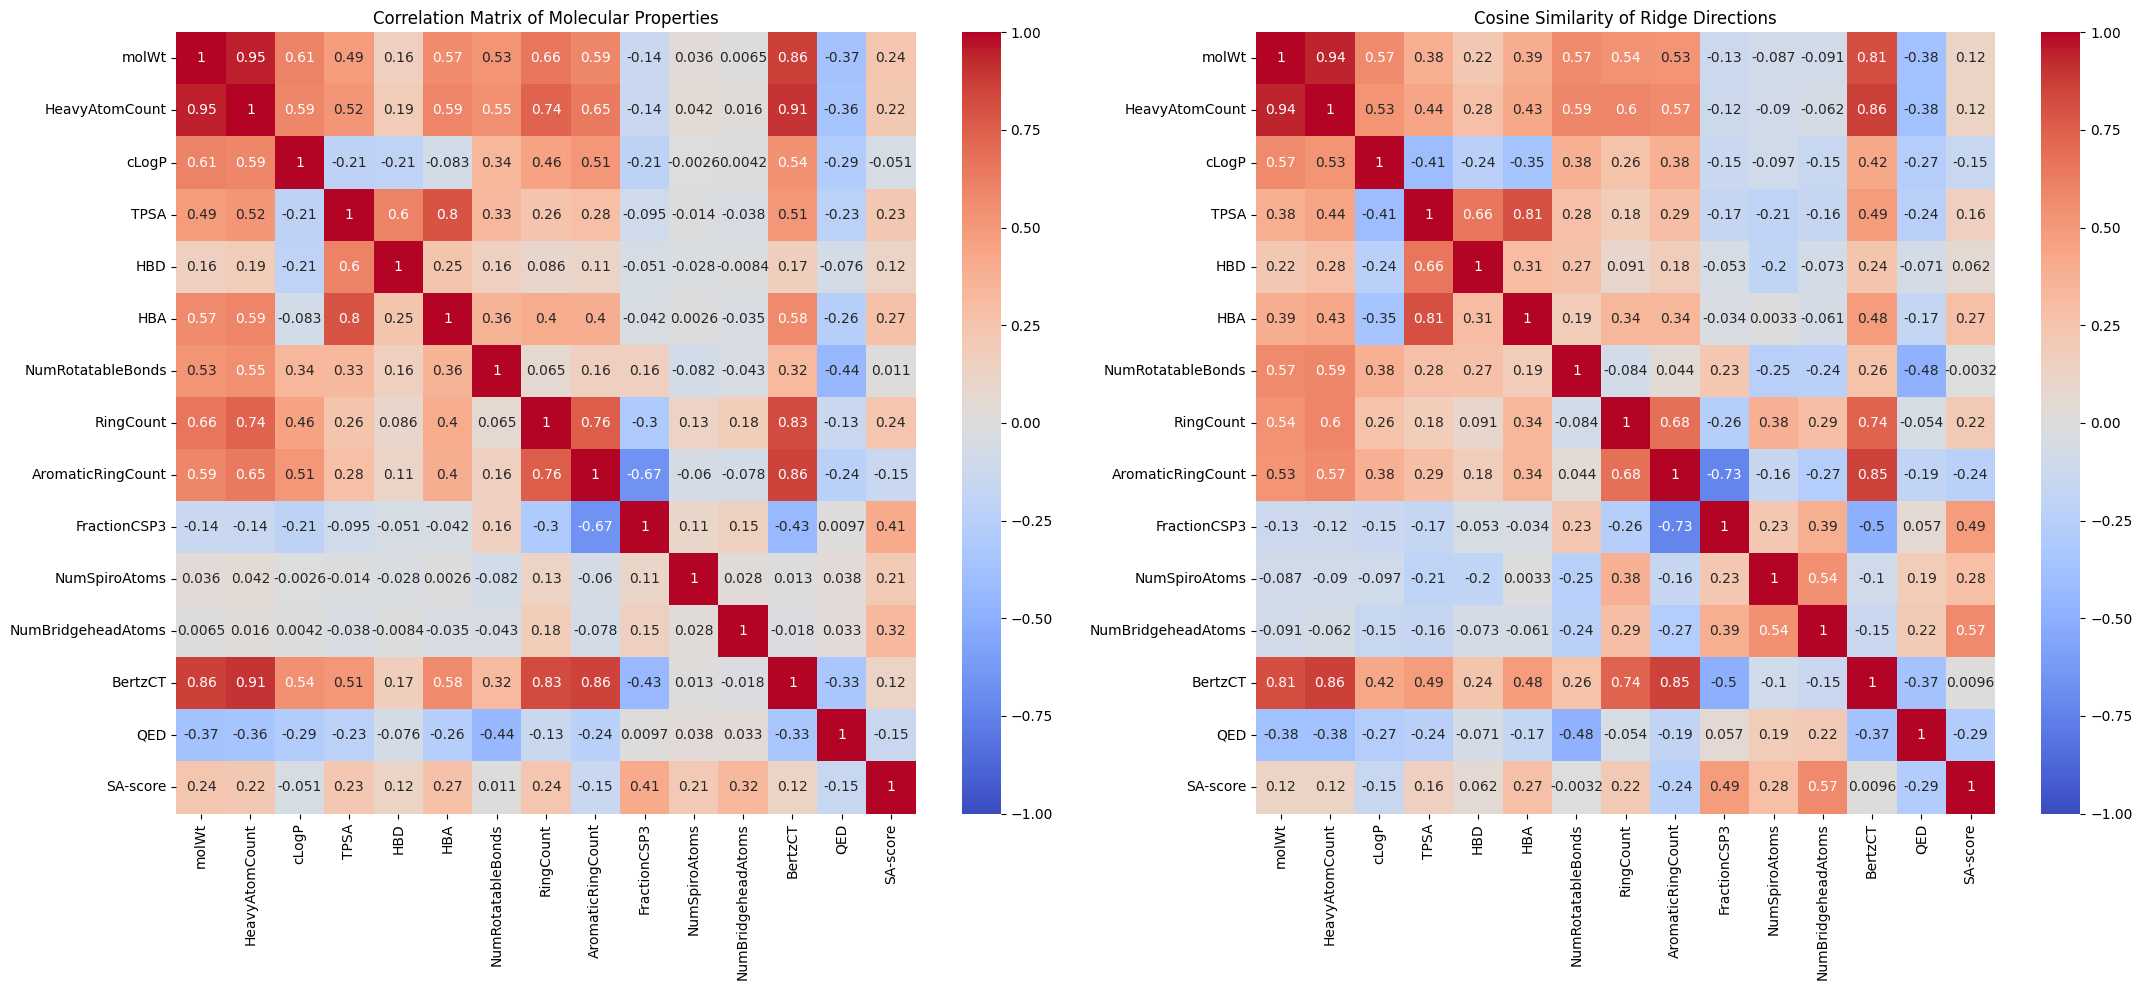

In [38]:
# plot correlation
corr_properties = Y.corr()
w = np.array(directions)
ridge_similarities = np.dot(w, w.T)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(corr_properties,annot=True, cmap="coolwarm",vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlation Matrix of Molecular Properties")
sns.heatmap(ridge_similarities,annot=True,cmap="coolwarm",vmin=-1, vmax=1, xticklabels=Y.columns, yticklabels=Y.columns, ax=axes[1])
axes[1].set_title("Cosine Similarity of Ridge Directions")

plt.tight_layout()
plt.show()